**Методы оптимизации**
## Дз №1 - "Кубическая аппроксимация в задаче поиска экстремумов функции одной переменной"

In [27]:
from typing import Callable
import math
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt

In [28]:
f = lambda x: x**2 - 3*x + x*math.log(x, math.e)

In [29]:
@dataclass
class HistoryItem:
    iteration: int
    x1: float | int
    x2: float | int
    x: float

# Поиск точки экстремума

In [30]:
df = lambda x, eps, f: (f(x+eps) - f(x-eps))/(2*eps)

# see: https://studfile.net/preview/1467149/page:17/
def cubic_min(
    a: float | int,
    b: float | int,
    f: Callable[[float | int], float],
    df: Callable[[float | int], float]
) -> float:
    fa, fb = f(a), f(b)
    dfa, dfb = df(a), df(b)

    # z = f'(a) + f'(b) - 3 * (f(b) - f(a)) / (b - a)
    z = dfa + dfb - 3*(fb - fa)/(b - a)

    # w = sqrt(z^2 - f'(a) * f'(b))
    w = math.sqrt(z**2 - dfa * dfb)

    # y = (z + w - dfa)/(dfb - dfa + 2w)
    y = (z + w - dfa)/(dfb - dfa + 2*w)

    # x = a + y(b-a)
    x = a + y*(b-a)

    return x


# phi(x) = c_0 (x-a)^3 + c_1 (x-a)^2 + c_2 (x-a) + c_3 
# see: https://studfile.net/preview/1467149/page:17/
def cubic_approx(
    f: Callable[[float | int], float],
    df: Callable[[float | int], float],
    a: float | int,
    b: float | int,
    eps: float=0.0001,
    max_iter: int=100
) -> tuple[float, list[HistoryItem]]:
    history = []

    for iter in range(max_iter):
        if abs(a-b) < eps: break
        
        x = cubic_min(a, b, f, df)
        dfx = df(x)

        history.append(HistoryItem(iter, a, b, x))

        if dfx < 0: a = x
        else:       b = x

    return (a + b)/2, history

In [31]:
res, history = cubic_approx(
    f,
    lambda x: df(x, 1e-7, f),
    1, 2
)
print(res)

0.9999999994319118


# Визуализации

## Визуализация итераций аппроксимации

In [32]:
def cubic_poly_value(x, x1, x2, f1, f2, df1, df2):
    h = x2 - x1
    if abs(h) < 1e-10: return f1
    a0 = f1
    a1 = df1
    rhs1 = f2 - f1 - df1 * h
    rhs2 = df2 - df1
    a3 = (rhs2 - 2*rhs1/h) / (h**2)
    a2 = (rhs1 - h**3*a3) / (h**2)
    t = x - x1
    return a0 + a1*t + a2*t**2 + a3*t**3

In [33]:
def plot_iterations(f: Callable[[float], float],
                    df: Callable[[float], float],
                    history: list[HistoryItem],
                    iterations_to_plot: list[int] = [1,2,3,4,5]):
    iterations_to_plot = [i for i in iterations_to_plot if i <= len(history)]
    n_plots = len(iterations_to_plot)
    fig, axes = plt.subplots(n_plots, 2, figsize=(15, 4*n_plots))
    
    if n_plots == 1:
        axes = np.array([axes])
    
    x_plot = np.linspace(0.5, 3.5, 500)
    y_plot = np.array([f(x) for x in x_plot])
    
    for idx, hist_idx in enumerate(iterations_to_plot):
        item = history[hist_idx-1]
        x1, x2, x_star = item.x1, item.x2, item.x
        f1, f2 = f(x1), f(x2)
        df1, df2 = df(x1), df(x2)
        
        # --- Левая панель: исходная функция ---
        ax_left = axes[idx][0]
        ax_left.plot(x_plot, y_plot, 'b-', label='f(x)')
        ax_left.axvline(x=x1, color='g', linestyle='--', label=f'x1={x1:.4f}')
        ax_left.axvline(x=x2, color='r', linestyle='--', label=f'x2={x2:.4f}')
        ax_left.axvline(x=x_star, color='purple', linestyle=':', label=f'x*={x_star:.4f}')
        ax_left.scatter([x1,x2,x_star], [f1,f2,f(x_star)], color=['green','red','purple'], s=50)
        ax_left.set_title(f'Итерация {item.iteration}: исходная функция')
        ax_left.set_xlabel('x')
        ax_left.set_ylabel('f(x)')
        ax_left.grid(True, alpha=0.3)
        ax_left.legend()
        
        # --- Правая панель: кубическая аппроксимация ---
        ax_right = axes[idx][1]
        x_cubic = np.linspace(x1, x2, 200)
        y_cubic = np.array([cubic_poly_value(x, x1, x2, f1, f2, df1, df2) for x in x_cubic])
        y_dense = np.array([f(x) for x in x_cubic])
        
        ax_right.plot(x_cubic, y_cubic, 'orange', label='Кубическая аппроксимация')
        ax_right.plot(x_cubic, y_dense, 'b--', alpha=0.7, label='f(x)')
        ax_right.scatter([x_star], [f(x_star)], color='purple', marker='*', s=80, label=f'x*={x_star:.4f}')
        ax_right.scatter([x1,x2], [f1,f2], color=['green','red'], s=50)
        ax_right.axvline(x=x1, color='g', linestyle='--', alpha=0.7)
        ax_right.axvline(x=x2, color='r', linestyle='--', alpha=0.7)
        ax_right.set_title(f'Итерация {item.iteration}: кубическая аппроксимация')
        ax_right.set_xlabel('x')
        ax_right.set_ylabel('p(x)')
        ax_right.grid(True, alpha=0.3)
        ax_right.legend()
        
        max_error = np.max(np.abs(y_cubic - y_dense))
        ax_right.text(0.02, 0.98, f'Max error: {max_error:.4e}',
                      transform=ax_right.transAxes, verticalalignment='top',
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()


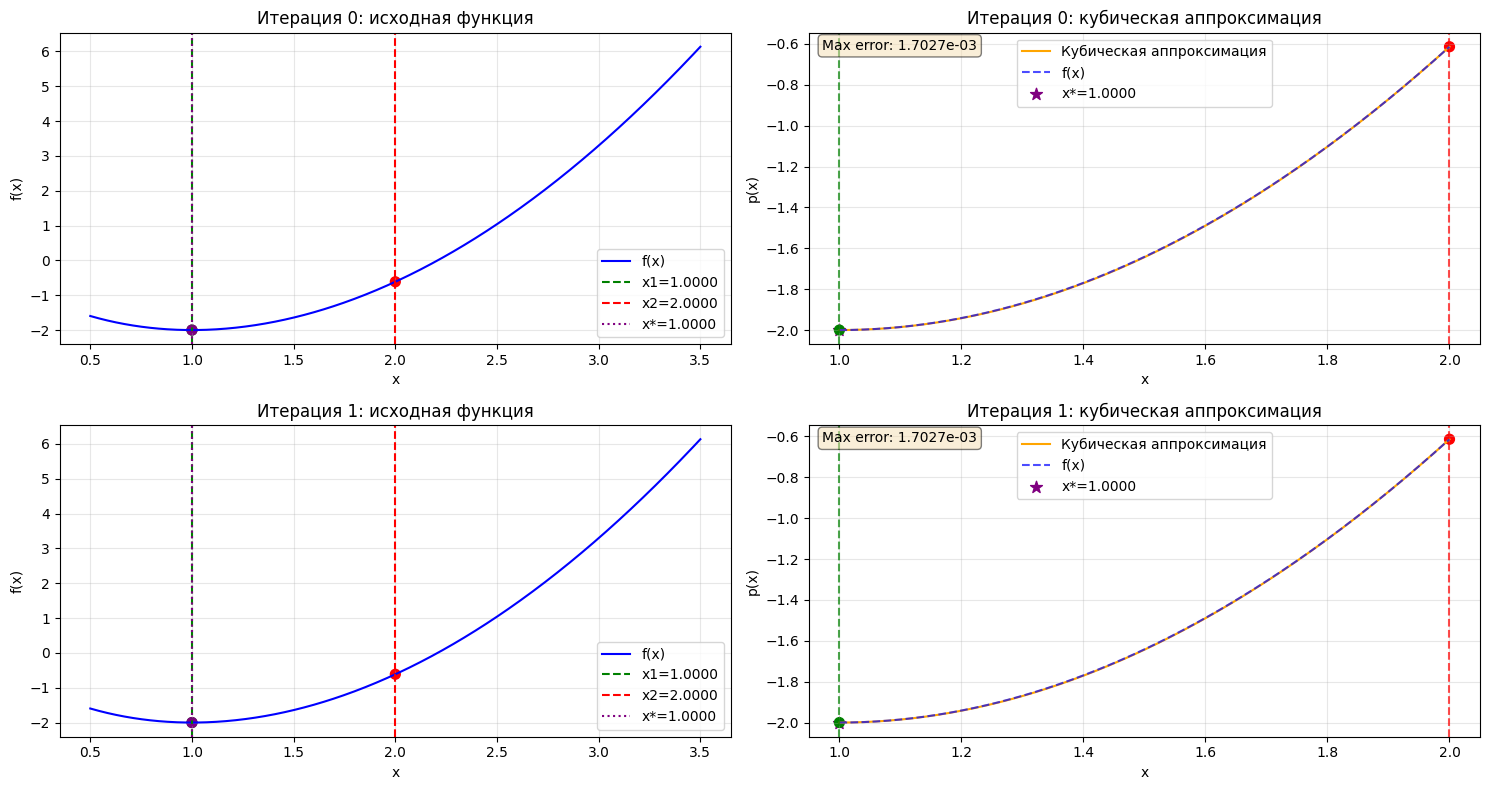

In [34]:
plot_iterations(
    f,
    lambda x: df(x, 1e-7, f),
    history
)

## Визуализация сходимости

In [35]:
def plot_convergence(history: list[HistoryItem]):
    iterations = [h.iteration for h in history]
    x_stars = [h.x for h in history]
    interval_lengths = [h.x2 - h.x1 for h in history]
    
    fig, axes = plt.subplots(1, 2, figsize=(14,5))
    
    # Интервал
    axes[0].semilogy(iterations, interval_lengths, 'bo-', linewidth=2)
    axes[0].set_title('Сходимость длины интервала')
    axes[0].set_xlabel('Итерация')
    axes[0].set_ylabel('Длина интервала')
    axes[0].grid(True, alpha=0.3)
    
    # Точка минимума
    axes[1].plot(iterations, x_stars, 'ro-', linewidth=2)
    axes[1].axhline(y=x_stars[-1], color='g', linestyle='--', alpha=0.5, label=f'Финальное x*={x_stars[-1]:.4f}')
    axes[1].set_title('Сходимость точки минимума')
    axes[1].set_xlabel('Итерация')
    axes[1].set_ylabel('x*')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

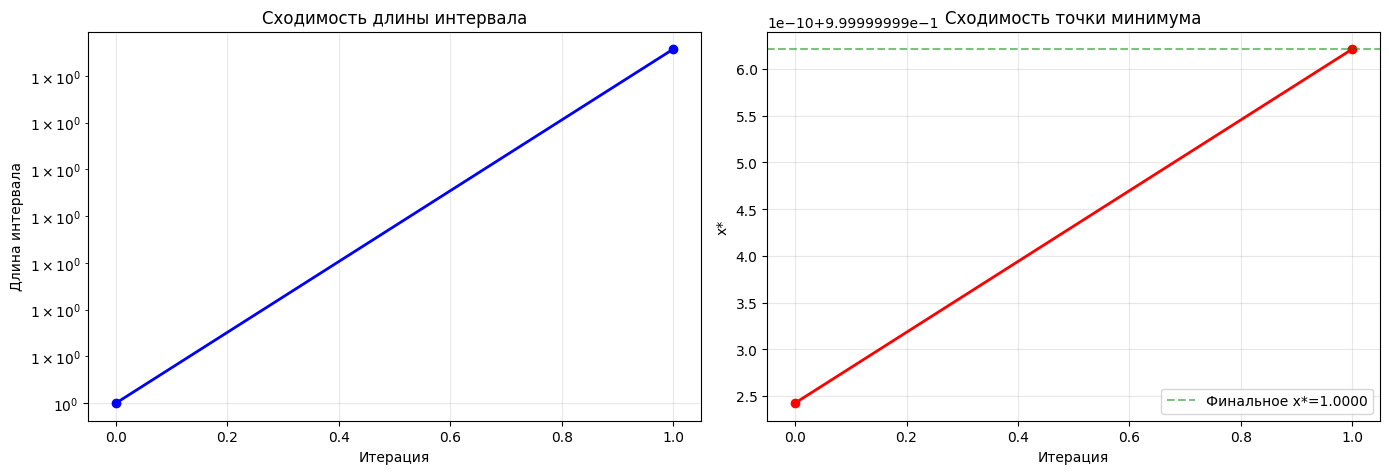

In [36]:
plot_convergence(history)